<a href="https://colab.research.google.com/github/Kommera-Harihansika/NexTune/blob/main/earphones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 4 CSV files:
  → headphones_raw.csv
  → indian_wireless_headphones_scraped_data.csv
  → amazon_earphones_market_data (1).csv
  → combined_clean_data.csv
✅ Loaded headphones_raw.csv — 148 rows
✅ Loaded indian_wireless_headphones_scraped_data.csv — 44 rows
✅ Loaded amazon_earphones_market_data (1).csv — 250 rows
✅ Loaded combined_clean_data.csv — 148 rows

✅ Total combined rows : 590
📁 Files loaded        : 4

🔧 Cleaning data...
Removed 441 duplicates

✅ Final clean dataset : 148 unique products

📁 Products per file:
source_file
headphones_raw.csv    148

🤖 Training model...
   Training : 118 products
   Testing  : 30 products

       MODEL PERFORMANCE RESULTS
  Total Products  : 148
  Files Combined  : 4
  MAE             : Rs.400.79
  R² Score        : -0.479
  Accuracy        : 59.4%


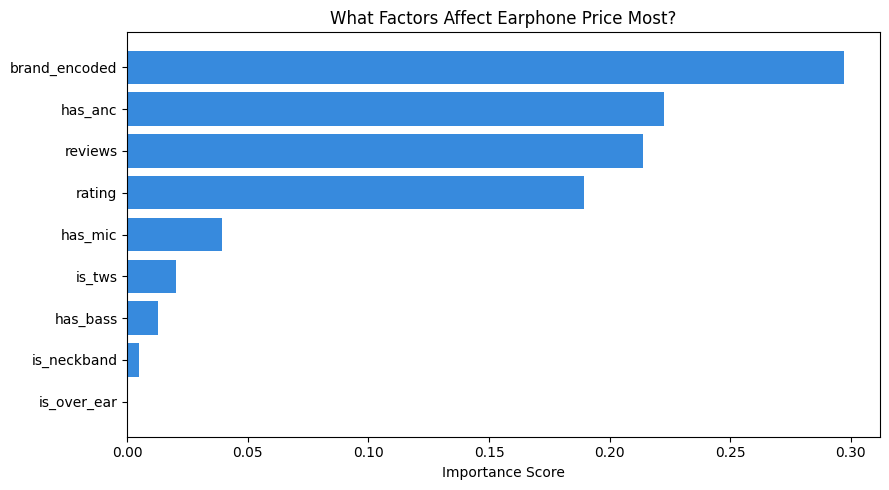

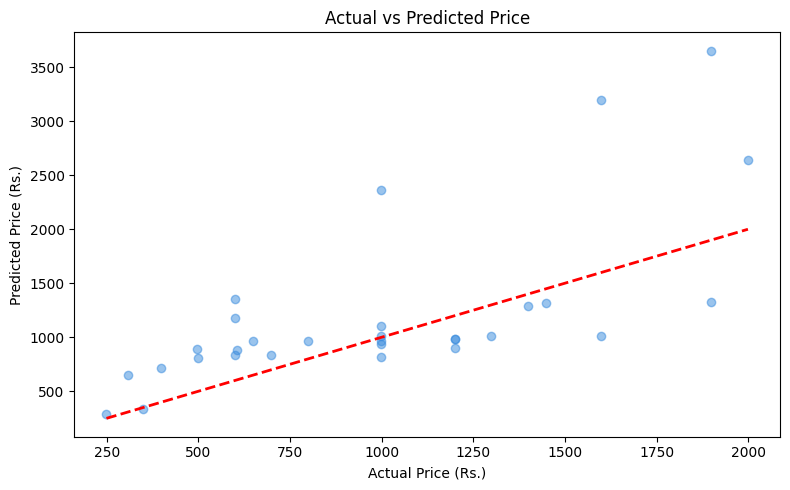

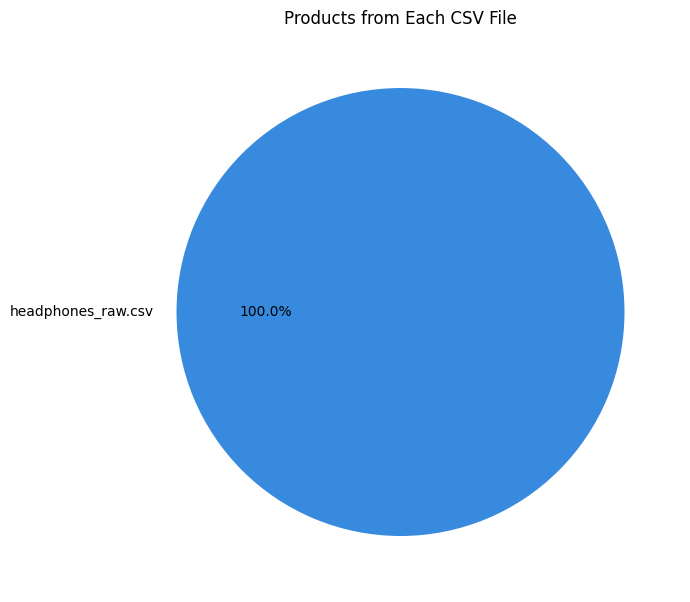


✅ Everything saved to Google Drive folder: earphones_data/
   Files saved:
   → price_model.pkl
   → label_encoder.pkl
   → combined_clean_data.csv
   → feature_importance.png
   → actual_vs_predicted.png
   → files_contribution.png

       PREDICTION RESULT
  Brand      : boAt
  ANC        : Yes
  TWS        : Yes
  Mic        : Yes
  Neckband   : No
  Over-Ear   : No
  Extra Bass : Yes
----------------------------------------
  Predicted  : Rs.3,915
  Range      : Rs.3,524 – Rs.4,307


In [4]:
# ============================================================
#   STEP 1 — Install libraries
# ============================================================
!pip install pandas scikit-learn matplotlib seaborn -q

# ============================================================
#   STEP 2 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
#   STEP 3 — Load ALL CSV files from a Drive folder
# ============================================================
import pandas as pd
import numpy as np
import os
import glob

# ── PUT ALL YOUR CSV FILES IN ONE GOOGLE DRIVE FOLDER ──
# Change this path to your folder name
FOLDER_PATH = "/content/drive/MyDrive/earphones_data/"

# Find all CSV files in that folder
csv_files = glob.glob(FOLDER_PATH + "*.csv")
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  → {os.path.basename(f)}")

# Load and combine all
all_dfs = []
for filepath in csv_files:
    try:
        df_temp = pd.read_csv(filepath)
        df_temp["source_file"] = os.path.basename(filepath)
        all_dfs.append(df_temp)
        print(f"✅ Loaded {os.path.basename(filepath)} — {len(df_temp)} rows")
    except Exception as e:
        print(f"❌ Failed: {filepath} — {e}")

# Combine all into one dataframe
df = pd.concat(all_dfs, ignore_index=True)
print(f"\n✅ Total combined rows : {len(df)}")
print(f"📁 Files loaded        : {len(all_dfs)}")

# ============================================================
#   STEP 4 — Clean Combined Data
# ============================================================
from sklearn.preprocessing import LabelEncoder

print("\n🔧 Cleaning data...")

df["price"] = (df["price"]
               .astype(str)
               .str.replace(",", "")
               .str.extract(r"(\d+)")[0]
               .astype(float))

df["rating"] = (df["rating"]
                .astype(str)
                .str.extract(r"([\d.]+)")[0]
                .astype(float))
df["rating"] = df["rating"].fillna(df["rating"].mean())

df["reviews"] = (df["reviews"]
                 .astype(str)
                 .str.replace(",", "")
                 .str.extract(r"(\d+)")[0]
                 .fillna(0)
                 .astype(int))

df["has_anc"]     = df["name"].str.contains("ANC|noise cancel|active noise", case=False, na=False).astype(int)
df["is_tws"]      = df["name"].str.contains("TWS|truly wireless|true wireless", case=False, na=False).astype(int)
df["has_mic"]     = df["name"].str.contains("mic|microphone", case=False, na=False).astype(int)
df["is_neckband"] = df["name"].str.contains("neckband|neck band", case=False, na=False).astype(int)
df["is_over_ear"] = df["name"].str.contains("over.ear|over ear|overhead", case=False, na=False).astype(int)
df["has_bass"]    = df["name"].str.contains("bass|extra bass", case=False, na=False).astype(int)

df["brand"] = df["brand"].fillna("Unknown")
le = LabelEncoder()
df["brand_encoded"] = le.fit_transform(df["brand"].astype(str))

before = len(df)
if "asin" in df.columns:
    df = df.drop_duplicates(subset=["asin"])
else:
    df = df.drop_duplicates(subset=["name", "price"])
after = len(df)
print(f"Removed {before - after} duplicates")

df = df[(df["price"] > 100) & (df["price"] < 50000)]
df = df.dropna(subset=["price"])

print(f"\n✅ Final clean dataset : {len(df)} unique products")
print("\n📁 Products per file:")
print(df["source_file"].value_counts().to_string())

# ============================================================
#   STEP 5 — Train ML Model
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "rating", "reviews", "has_anc", "is_tws",
    "has_mic", "is_neckband", "is_over_ear",
    "has_bass", "brand_encoded"
]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n🤖 Training model...")
print(f"   Training : {len(X_train)} products")
print(f"   Testing  : {len(X_test)} products")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

preds    = model.predict(X_test)
mae      = mean_absolute_error(y_test, preds)
r2       = r2_score(y_test, preds)
accuracy = max(0, 100 - (mae / y_test.mean() * 100))

print("\n" + "=" * 45)
print("       MODEL PERFORMANCE RESULTS")
print("=" * 45)
print(f"  Total Products  : {len(df)}")
print(f"  Files Combined  : {len(all_dfs)}")
print(f"  MAE             : Rs.{mae:.2f}")
print(f"  R² Score        : {r2:.3f}")
print(f"  Accuracy        : {accuracy:.1f}%")
print("=" * 45)

# ============================================================
#   STEP 6 — Charts
# ============================================================
import matplotlib.pyplot as plt

# Feature importance
plt.figure(figsize=(9, 5))
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#378ADD")
plt.xlabel("Importance Score")
plt.title("What Factors Affect Earphone Price Most?")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/earphones_data/feature_importance.png")
plt.show()

# Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color="#378ADD")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price (Rs.)")
plt.ylabel("Predicted Price (Rs.)")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/earphones_data/actual_vs_predicted.png")
plt.show()

# Files contribution pie chart
plt.figure(figsize=(7, 7))
file_counts = df["source_file"].value_counts()
plt.pie(file_counts.values,
        labels=file_counts.index,
        autopct="%1.1f%%",
        colors=["#378ADD","#1D9E75","#D85A30","#BA7517","#D4537E"])
plt.title("Products from Each CSV File")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/earphones_data/files_contribution.png")
plt.show()

# ============================================================
#   STEP 7 — Save Model to Google Drive
# ============================================================
import pickle

MODEL_PATH = "/content/drive/MyDrive/earphones_data/"

with open(MODEL_PATH + "price_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open(MODEL_PATH + "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

df.to_csv(MODEL_PATH + "combined_clean_data.csv", index=False)

print(f"\n✅ Everything saved to Google Drive folder: earphones_data/")
print("   Files saved:")
print("   → price_model.pkl")
print("   → label_encoder.pkl")
print("   → combined_clean_data.csv")
print("   → feature_importance.png")
print("   → actual_vs_predicted.png")
print("   → files_contribution.png")

# ============================================================
#   STEP 8 — Test Prediction
# ============================================================
def predict_price(brand, has_anc, is_tws, has_mic,
                  is_neckband, is_over_ear, has_bass,
                  rating=4.0, reviews=1000):
    try:
        brand_encoded = le.transform([brand])[0]
    except:
        brand_encoded = 0

    input_df = pd.DataFrame([{
        "rating":        rating,
        "reviews":       reviews,
        "has_anc":       int(has_anc),
        "is_tws":        int(is_tws),
        "has_mic":       int(has_mic),
        "is_neckband":   int(is_neckband),
        "is_over_ear":   int(is_over_ear),
        "has_bass":      int(has_bass),
        "brand_encoded": brand_encoded
    }])

    price = model.predict(input_df)[0]
    print("\n" + "=" * 40)
    print("       PREDICTION RESULT")
    print("=" * 40)
    print(f"  Brand      : {brand}")
    print(f"  ANC        : {'Yes' if has_anc else 'No'}")
    print(f"  TWS        : {'Yes' if is_tws else 'No'}")
    print(f"  Mic        : {'Yes' if has_mic else 'No'}")
    print(f"  Neckband   : {'Yes' if is_neckband else 'No'}")
    print(f"  Over-Ear   : {'Yes' if is_over_ear else 'No'}")
    print(f"  Extra Bass : {'Yes' if has_bass else 'No'}")
    print("-" * 40)
    print(f"  Predicted  : Rs.{price:,.0f}")
    print(f"  Range      : Rs.{price*0.9:,.0f} – Rs.{price*1.1:,.0f}")
    print("=" * 40)

predict_price(
    brand="boAt", has_anc=True, is_tws=True,
    has_mic=True, is_neckband=False,
    is_over_ear=False, has_bass=True,
    rating=4.2, reviews=5000
)